# Apriori Algorithm from Scratch 🛒

## 🛒 Theoretical Background
The Apriori algorithm is used for market basket analysis to find frequent itemsets and derive association rules.
- **Support**: Probability that a transaction contains item A and B.
- **Confidence**: Probability that a transaction contains item B given it contains item A.
- **Lift**: Ratio of observed frequency of A and B together to that expected if they were independent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [ ]:

# Dummy transaction data
dataset = [['Milk', 'Bread', 'Eggs'],
           ['Milk', 'Bread'],
           ['Milk', 'Eggs'],
           ['Bread', 'Eggs'],
           ['Milk', 'Bread', 'Eggs', 'Coke']]

# Apriori Implementation with candidate pruning
def get_support(df, itemset):
    return (df[list(itemset)].all(axis=1)).sum() / len(df)

def generate_candidates(prev_frequent, k):
    """Join step: combine (k-1)-itemsets that share their first k-2 items,
    then prune step: drop any candidate with an infrequent (k-1)-subset
    (the anti-monotonicity property Apriori relies on to avoid testing
    every combination like brute-force counting would)."""
    prev_frequent_set = set(prev_frequent)
    candidates = set()
    prev_list = sorted(prev_frequent)
    for i in range(len(prev_list)):
        for j in range(i + 1, len(prev_list)):
            a, b = prev_list[i], prev_list[j]
            if a[:k-2] == b[:k-2]:
                candidate = tuple(sorted(set(a) | set(b)))
                if len(candidate) == k:
                    # Prune: every (k-1)-subset of the candidate must itself be frequent
                    if all(sub in prev_frequent_set for sub in combinations(candidate, k - 1)):
                        candidates.add(candidate)
    return candidates

# One-hot encoding
items = sorted(list(set([item for sublist in dataset for item in sublist])))
encoded_data = []
for trans in dataset:
    encoded_data.append([1 if item in trans else 0 for item in items])
df = pd.DataFrame(encoded_data, columns=items)

# Get frequent itemsets (min_support = 0.4), generating candidates
# level-by-level and pruning with the frequent (k-1)-itemsets instead
# of testing every combination of every size up front.
min_support = 0.4
frequent_itemsets = []

k = 1
candidates_k = [(item,) for item in items]
while candidates_k:
    frequent_k = []
    for combo in candidates_k:
        sup = get_support(df, combo)
        if sup >= min_support:
            frequent_itemsets.append({'itemset': combo, 'support': sup})
            frequent_k.append(combo)
    if not frequent_k:
        break
    k += 1
    candidates_k = sorted(generate_candidates(frequent_k, k))

fi_df = pd.DataFrame(frequent_itemsets)
print(fi_df)


### 📊 Visualization: Support of Itemsets

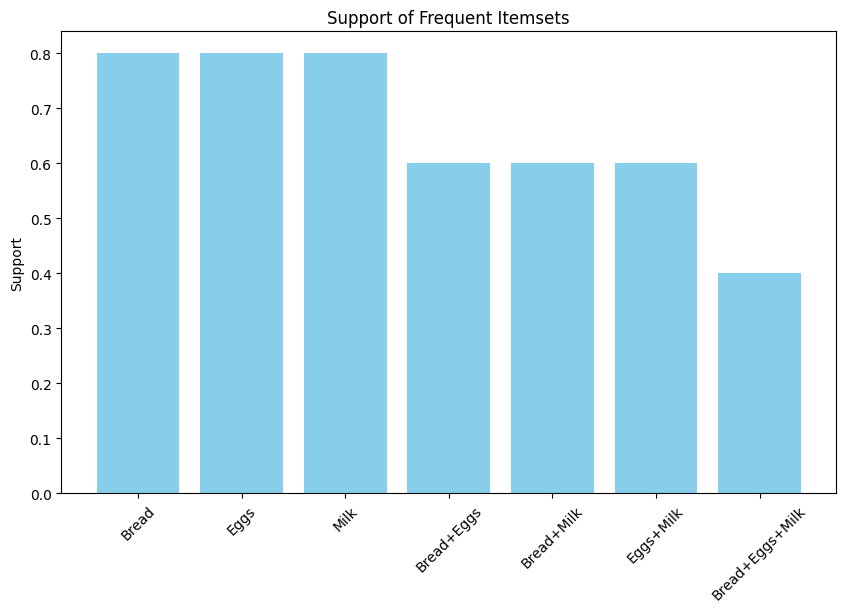

In [3]:
plt.figure(figsize=(10, 6))
plt.bar(['+'.join(i) for i in fi_df['itemset']], fi_df['support'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Support of Frequent Itemsets')
plt.ylabel('Support')
plt.show()

### 📏 Association Rule Mining (Confidence & Lift)
The markdown above defines Confidence and Lift, but finding frequent
itemsets alone doesn't produce rules. For every frequent itemset,
generate all non-empty proper-subset antecedents `A -> B` and keep
the rules meeting a minimum confidence threshold.

In [ ]:
support_lookup = {row['itemset']: row['support'] for row in frequent_itemsets}
min_confidence = 0.6

rules = []
for itemset, itemset_support in support_lookup.items():
    if len(itemset) < 2:
        continue
    for r in range(1, len(itemset)):
        for antecedent in combinations(itemset, r):
            antecedent = tuple(sorted(antecedent))
            consequent = tuple(sorted(set(itemset) - set(antecedent)))

            antecedent_support = support_lookup.get(antecedent)
            consequent_support = support_lookup.get(consequent)
            if antecedent_support is None or consequent_support is None:
                continue

            confidence = itemset_support / antecedent_support
            if confidence < min_confidence:
                continue

            lift = confidence / consequent_support
            rules.append({
                'antecedent': antecedent,
                'consequent': consequent,
                'support': itemset_support,
                'confidence': confidence,
                'lift': lift,
            })

rules_df = pd.DataFrame(rules).sort_values('lift', ascending=False).reset_index(drop=True)
print(rules_df)